# 09.2 — Curvature or density? Decoupling the two on the Swiss roll

Notebook 09.1 found that on the Swiss roll the controlled partial of exact `||H||` against a
global probe's local R² is negative for an intrinsic-linear label, and that it is negative even
for an ambient-linear label under ridge shrinkage. On that roll curvature and sampling density
both fall outward, with `rho(||H||, log r) = -0.59`, so the sign could come from either.

This notebook keeps the surface and the labels fixed and changes only how `t` is sampled, so
the surface density is `(1 + t²)^(beta/2)` relative to area-uniform:

- `beta = -1`: `sklearn`'s uniform-in-`t` sampling. Density falls outward. Density and curvature
  positively coupled.
- `beta = 0`: area-uniform. Density constant on the surface. Coupling ≈ 0.
- `beta = +1`: density rises outward. Density and curvature negatively coupled.

The curvature field is identical in all three. If the partial follows curvature it stays put
across `beta`; if it follows density leaking past the `log_knn_radius` control it moves with the
coupling. Same sealed pipeline as 09.1. No cache.

One control that cannot be added here: the exact surface density. On this surface it is a
function of `t` alone, and so is `||H||`, so their ranks coincide and residualising on the exact
density removes the curvature column entirely. The empirical `log_knn_radius` is usable only
because a k-NN ball on a curled sheet also varies with `h` and with cross-turn short-circuits.
That is a property of one-parameter surfaces, and one reason the sphere fixture comes next.

## §1. Setup

In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

from pu_manifold import curvature_probe
from pu_manifold import physics_curvature_probe as pcp

SEED = 0
N_POINTS = 3000
K = 256
N_ANCHORS = 256
N_PERMUTATIONS = 5000
BETAS = (-1, 0, 1)
T_LO, T_HI, H_MAX = 1.5 * np.pi, 4.5 * np.pi, 21.0        # sklearn's make_swiss_roll ranges
print(f"numpy {np.__version__}; alpha={pcp.ALPHA_RIDGE}, folds={pcp.N_OOF_FOLDS}, controls={pcp.CONTROLS}")

numpy 2.5.1; alpha=100.0, folds=5, controls=('log_knn_radius', 'local_label_variance', 'local_evaluation_count')


## §2. Three rolls, one surface

`X(t, h) = (t cos t, h, t sin t)`, `t ∈ [1.5π, 4.5π]`, `h ∈ [0, 21]`, as in `sklearn`. Area
element is `||∂_t|| dt dh = sqrt(1 + t²) dt dh`. To get surface density `∝ (1 + t²)^(beta/2)`
the `t` marginal must be `∝ (1 + t²)^((beta + 1)/2)`; `beta = -1` recovers uniform `t`. Sampled
by inverse CDF on a fine grid. Each roll is centred and divided by its own global standard
deviation, and the exact curvature is rescaled by the same scalar.

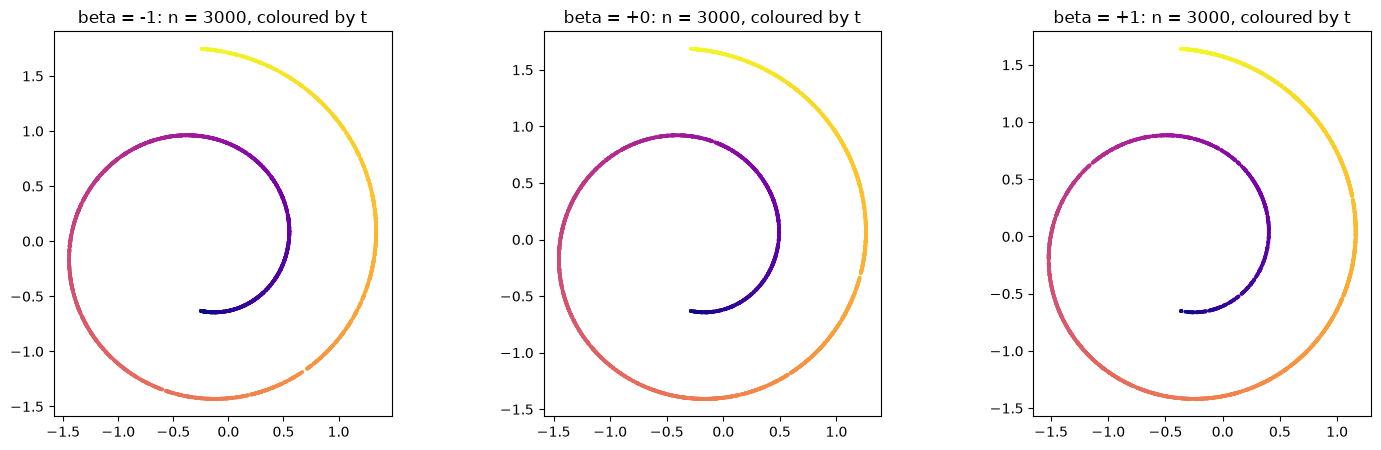

beta=-1: ||H|| p05/p50/p95 = [0.582 0.852 1.563], t p05/p50/p95 = [ 5.16  9.35 13.64]
beta=+0: ||H|| p05/p50/p95 = [0.591 0.782 1.497], t p05/p50/p95 = [ 5.52 10.45 13.8 ]
beta=+1: ||H|| p05/p50/p95 = [0.594 0.732 1.361], t p05/p50/p95 = [ 6.12 11.28 13.89]


In [2]:
def sample_t(beta, n, rng):
    grid = np.linspace(T_LO, T_HI, 20001)
    pdf = (1.0 + grid**2) ** ((beta + 1) / 2)
    cdf = np.concatenate([[0.0], np.cumsum(0.5 * (pdf[1:] + pdf[:-1]) * np.diff(grid))])
    return np.interp(rng.random(n) * cdf[-1], cdf, grid)

def make_roll(beta, seed):
    rng = np.random.default_rng(seed)
    t = sample_t(beta, N_POINTS, rng)
    h = rng.random(N_POINTS) * H_MAX
    X_raw = np.stack([t * np.cos(t), h, t * np.sin(t)], 1)
    s = float(X_raw.std())
    X = (X_raw - X_raw.mean(0)) / s
    dt = np.stack([np.cos(t) - t * np.sin(t), np.zeros_like(t), np.sin(t) + t * np.cos(t)], 1)
    return {"beta": beta, "t": t, "h": h, "X": X, "s": s,
            "H": curvature_probe.swiss_roll_analytic_H_scaled(t, s),
            "log_density_exact": (beta / 2) * np.log1p(t**2),
            "e_t": dt / np.linalg.norm(dt, axis=1, keepdims=True)}

rolls = [make_roll(b, SEED) for b in BETAS]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, r in zip(axes, rolls):
    sc = ax.scatter(r["X"][:, 0], r["X"][:, 2], c=r["t"], cmap="plasma", s=3)
    ax.set_aspect("equal"); ax.set_title(f"beta = {r['beta']:+d}: n = {N_POINTS}, coloured by t")
plt.tight_layout(); plt.show()
for r in rolls:
    print(f"beta={r['beta']:+d}: ||H|| p05/p50/p95 = {np.percentile(r['H'], [5, 50, 95]).round(3)}, "
          f"t p05/p50/p95 = {np.percentile(r['t'], [5, 50, 95]).round(2)}")

## §3. Anchors, neighbourhoods, and the coupling each roll actually has

Frozen anchor rule, sealed `knn_panel`. The first thing to check is that the manipulation
worked: `rho(||H||, log r)` at the anchors should go from negative, through about zero, to
positive.

In [3]:
for r in rolls:
    split = pcp.anchor_indices(N_POINTS, pcp.SPLIT_SEED, pcp.HOLDOUT_FRACTION, N_ANCHORS, pcp.ANCHOR_DRAW_SEED)
    r["anchor_idx"] = a = split["anchor_idx"]
    r["panel"] = pcp.knn_panel(r["X"], a, K)
    r["log_r"] = r["panel"]["log_knn_radius"]
    r["rho_H_logr"] = spearmanr(r["H"][a], r["log_r"]).statistic
    print(f"beta={r['beta']:+d}: rho(||H||, log r) at anchors = {r['rho_H_logr']:+.3f}   "
          f"r/R = {np.median(r['panel']['distances'][:, -1]) / np.median(np.linalg.norm(r['X'] - r['X'].mean(0), axis=1)):.3f}")

beta=-1: rho(||H||, log r) at anchors = -0.721   r/R = 0.610
beta=+0: rho(||H||, log r) at anchors = -0.115   r/R = 0.582
beta=+1: rho(||H||, log r) at anchors = +0.504   r/R = 0.568


## §4. The pipeline on every roll and every label

Two label arms per roll: `y = h` at `alpha = 100` (the ridge null of 09.1) and `y = t`. For each,
the controlled partial of exact `||H||` against local R² under the frozen three controls.

In [4]:
def partial_with_p(x, y, Z):
    try:
        fw = pcp.permutation_fwer({0: x}, y, Z, N_PERMUTATIONS, pcp.PERMUTATION_SEED)
        return fw["per_d"][0]["observed_rho"], fw["per_d"][0]["p"]
    except ValueError:
        return np.nan, np.nan

def run(r, name, y):
    y = np.asarray(y, dtype=np.float64)
    y_hat = pcp.oof_ridge_predictions(r["X"], y, pcp.ALPHA_RIDGE, pcp.N_OOF_FOLDS, pcp.OOF_FOLD_SEED)
    loc = pcp.local_r2_panel(y, y_hat, r["panel"]["indices"], pcp.MIN_FINITE_NEIGHBOURS)
    r2, a = loc["r2"], r["anchor_idx"]
    Z = np.column_stack([r["log_r"], loc["local_label_variance"], loc["local_evaluation_count"]])
    raw = spearmanr(r["H"][a], r2, nan_policy="omit").statistic
    pf, ppf = partial_with_p(r["H"][a], r2, Z)
    return {"beta": r["beta"], "label": name, "r2": r2, "global_r2": 1 - np.sum((y - y_hat)**2) / np.sum((y - y.mean())**2),
            "raw": raw, "partial_frozen": pf, "p_frozen": ppf}

rows = []
for r in rolls:
    rows.append(run(r, "h (ridge null)", r["h"]))
    rows.append(run(r, "t", r["t"]))

print(f"{'beta':>5s} {'label':16s} {'rho(H,logr)':>11s} {'global R2':>9s} {'r2 p05':>8s} {'r2 p50':>8s} | {'raw rho':>8s} {'partial':>8s} {'p':>7s}")
for row in rows:
    r = next(x for x in rolls if x["beta"] == row["beta"])
    print(f"{row['beta']:+5d} {row['label']:16s} {r['rho_H_logr']:+11.3f} {row['global_r2']:9.3f} {np.nanpercentile(row['r2'], 5):8.3f} {np.nanmedian(row['r2']):8.3f} | "
          f"{row['raw']:+8.3f} {row['partial_frozen']:+8.3f} {row['p_frozen']:7.4f}")

 beta label            rho(H,logr) global R2   r2 p05   r2 p50 |  raw rho  partial       p
   -1 h (ridge null)        -0.721     0.996    0.951    0.985 |   -0.052   -0.254  0.0002
   -1 t                     -0.721     0.071  -60.282   -2.083 |   -0.770   -0.493  0.0002
   +0 h (ridge null)        -0.115     0.995    0.953    0.984 |   -0.005   +0.024  0.6987
   +0 t                     -0.115     0.144  -11.672   -0.544 |   -0.585   -0.758  0.0002
   +1 h (ridge null)        +0.504     0.995    0.950    0.984 |   +0.069   +0.383  0.0002
   +1 t                     +0.504     0.233  -21.968   -0.501 |   -0.134   -0.515  0.0002


## §5. The partial against the coupling

Each label arm as a line across `beta`. A flat line means the statistic follows curvature; a
line that tracks `rho(||H||, log r)` means it follows density leakage.

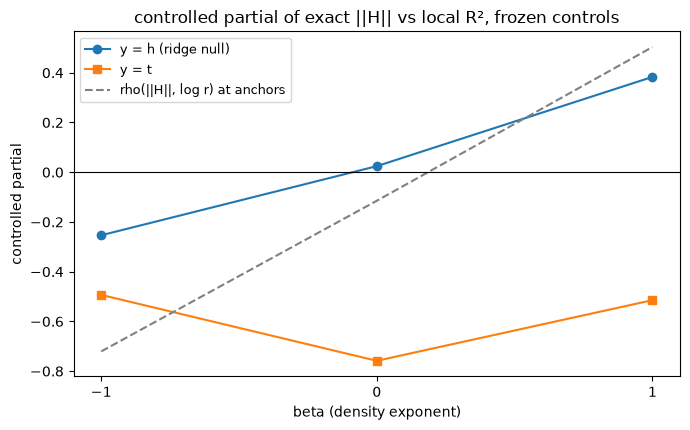

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.4))
coupling = [r["rho_H_logr"] for r in rolls]
for label, marker in (("h (ridge null)", "o"), ("t", "s")):
    vals = [row["partial_frozen"] for row in rows if row["label"] == label]
    ax.plot(BETAS, vals, marker=marker, label=f"y = {label}")
ax.plot(BETAS, coupling, ls="--", c="grey", label="rho(||H||, log r) at anchors")
ax.axhline(0, c="k", lw=0.8); ax.set_xticks(BETAS); ax.set_xlabel("beta (density exponent)")
ax.set_title("controlled partial of exact ||H|| vs local R², frozen controls"); ax.legend(fontsize=9)
ax.set_ylabel("controlled partial")
plt.tight_layout(); plt.show()

## §6. Read-out

Pass/fail on the manipulation and on the one thing known in advance. The sign behaviour of the
`t` arm across `beta` is the finding.

In [6]:
def get(label, beta, key):
    return next(row[key] for row in rows if row["label"] == label and row["beta"] == beta)

c = {r["beta"]: r["rho_H_logr"] for r in rolls}
t_parts = [get("t", b, "partial_frozen") for b in BETAS]
null_parts = [get("h (ridge null)", b, "partial_frozen") for b in BETAS]
lines = [
    ("manipulation worked: rho(||H||, log r) is < -0.3 at beta=-1, |.| < 0.2 at beta=0, > +0.3 at beta=+1",
     c[-1] < -0.3 and abs(c[0]) < 0.2 and c[1] > 0.3),
    ("t arm: same sign at every beta", len(set(np.sign(t_parts))) == 1),
    ("t arm: magnitude stable across beta (max/min |partial| < 2)", max(map(abs, t_parts)) / max(min(map(abs, t_parts)), 1e-9) < 2),
    ("ridge null: |partial| < 0.10 at beta=0 (no coupling to leak)", abs(null_parts[1]) < 0.10),
]
for text, ok in lines:
    print(f"{'PASS' if ok else 'FAIL'}  {text}")
print()
print("coupling rho(||H||, log r): " + "  ".join(f"beta={b:+d}: {c[b]:+.3f}" for b in BETAS))
print("t arm partial:              " + "  ".join(f"beta={b:+d}: {v:+.3f}" for b, v in zip(BETAS, t_parts)))
print("ridge-null partial:         " + "  ".join(f"beta={b:+d}: {v:+.3f}" for b, v in zip(BETAS, null_parts)))
verdict = ("follows curvature" if lines[1][1] and lines[2][1] else "moves with the density coupling")
null_tracks = np.sign(null_parts[0]) == np.sign(c[-1]) and np.sign(null_parts[2]) == np.sign(c[1])
print(f"\nWith the surface and label fixed and only the density-curvature coupling changed from "
      f"{c[-1]:+.2f} to {c[1]:+.2f}, the y = t partial {verdict}; the ridge-null partial "
      f"{'tracks the coupling sign for sign' if null_tracks else 'does not track the coupling'}, "
      f"which is what density leakage past the log-radius control looks like on its own.")

PASS  manipulation worked: rho(||H||, log r) is < -0.3 at beta=-1, |.| < 0.2 at beta=0, > +0.3 at beta=+1
PASS  t arm: same sign at every beta
PASS  t arm: magnitude stable across beta (max/min |partial| < 2)
PASS  ridge null: |partial| < 0.10 at beta=0 (no coupling to leak)

coupling rho(||H||, log r): beta=-1: -0.721  beta=+0: -0.115  beta=+1: +0.504
t arm partial:              beta=-1: -0.493  beta=+0: -0.758  beta=+1: -0.515
ridge-null partial:         beta=-1: -0.254  beta=+0: +0.024  beta=+1: +0.383

With the surface and label fixed and only the density-curvature coupling changed from -0.72 to +0.50, the y = t partial follows curvature; the ridge-null partial tracks the coupling sign for sign, which is what density leakage past the log-radius control looks like on its own.
